In [66]:
!pip install pyspark pillow pandas matplotlib seaborn exifread


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [67]:

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Image Metadata EDA") \
    .getOrCreate()

In [68]:
import os
from PIL import Image
from PIL.ExifTags import TAGS
import pandas as pd

def extract_metadata(image_path):
    data = {
        "file_name": os.path.basename(image_path),
        "format": None,
        "width": None,
        "height": None,
        "datetime": None,
        "camera_model": None
    }
    
    try:
        img = Image.open(image_path)
        data["format"] = img.format
        data["width"], data["height"] = img.size
        
        exif_data = img._getexif()
        
        if exif_data:
            for tag, value in exif_data.items():
                tag_name = TAGS.get(tag, tag)
                
                if tag_name == "DateTime":
                    data["datetime"] = value
                elif tag_name == "Model":
                    data["camera_model"] = value
                    
    except Exception as e:
        pass
    
    return data

In [55]:
image_folder =  "/Users/Bhavyasree/Downloads/input_photos"

metadata_list = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)
            metadata_list.append(extract_metadata(path))

spark_df = spark.createDataFrame(metadata_list)

spark_df.show(5)

[Stage 0:>                                                          (0 + 1) / 1]

+-----------------+-------------------+--------------------+------+------+-----+
|     camera_model|           datetime|           file_name|format|height|width|
+-----------------+-------------------+--------------------+------+------+-----+
|             NULL|               NULL|        IMG_7960.JPG|  JPEG|  2208| 1242|
|             NULL|               NULL|        IMG_0799.JPG|  JPEG|  2208| 1188|
|             NULL|               NULL|ff9d058a-133c-4b2...|  JPEG|  1200| 1600|
|         SM-A515F|2020:09:13 10:10:31| 20200913_101031.jpg|  JPEG|  1472| 3264|
|iPhone 12 Pro Max|2023:04:23 16:44:24|04D52997-78F0-468...|  JPEG|  2160| 3840|
+-----------------+-------------------+--------------------+------+------+-----+
only showing top 5 rows


In [69]:
import os

print(image_folder)
print(os.path.exists(image_folder))

/Users/Bhavyasree/Downloads/input_photos
True


In [70]:
print(os.listdir(image_folder))

['IMG_9323.HEIC', 'IMG_7960.JPG', 'IMG_3684.HEIC', 'IMG_4141.HEIC', 'a1d39914a2b445eca0d14e44c63ce49d.mov', 'filtered-735FF129-451C-45AE-A76F-6D7DA129CBCE.mp4', 'IMG_5300.HEIC', 'IMG_0552.HEIC', 'IMG_8162.HEIC', 'IMG_4454.HEIC', 'IMG_6469.HEIC', 'IMG_6193.HEIC', 'IMG_0799.JPG', 'ff9d058a-133c-4b29-94df-02827af3a4b2.jpg', 'F9698DCD-DAEE-46FB-AF45-6080CED78ACF.mp4', 'IMG_3811.HEIC', 'IMG_2353.HEIC', 'IMG_6740.HEIC', '20200913_101031.jpg', 'IMG_3407.HEIC', 'recorded-17786619472310.mp4', 'IMG_2646.HEIC', 'IMG_6828.HEIC', 'IMG_4456.MP4', '04D52997-78F0-4685-B642-C62DA9734D88.jpg', 'IMG_2884.HEIC', 'IMG_3796.HEIC', 'IMG_9231.heic', '5c575377-2677-47ce-9614-78fe30551c56.jpg', '5AB18219-D529-456F-9900-6E26980C7825.mp4', 'IMG_6717.HEIC', 'IMG_0216.JPG', 'IMG_3450.HEIC', '20200906_115417.jpg', 'IMG_8089.heic', 'a9f14756-bd48-48f4-b538-9659c1eb87c6.mp4', 'IMG_4845.JPG', 'IMG_0631(1).HEIC', 'IMG_0905.HEIC', 'IMG_7540.HEIC', 'IMG_0362.JPG', 'IMG_3446.HEIC', 'IMG_0544.HEIC', 'IMG_2129.HEIC', 'IMG_36

In [71]:
for root, dirs, files in os.walk(image_folder):
    print("FOLDER:", root)
    print("FILES:", files[:5])
    break

FOLDER: /Users/Bhavyasree/Downloads/input_photos
FILES: ['IMG_9323.HEIC', 'IMG_7960.JPG', 'IMG_3684.HEIC', 'IMG_4141.HEIC', 'a1d39914a2b445eca0d14e44c63ce49d.mov']


In [72]:
metadata_list = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)
            try:
                meta = extract_metadata(path)
                metadata_list.append(meta)
            except Exception as e:
                print("Error:", file)

In [73]:
from pyspark.sql.functions import col

spark_df = spark_df.filter(
    col("width").isNotNull() & col("height").isNotNull()
)

In [57]:
from pyspark.sql.functions import col

spark_df = spark_df.withColumn(
    "resolution",
    col("width") * col("height")
)

In [74]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def categorize(res):
    if res < 1_000_000:
        return "Low"
    elif res < 5_000_000:
        return "Medium"
    else:
        return "High"

categorize_udf = udf(categorize, StringType())

spark_df = spark_df.withColumn(
    "size_category",
    categorize_udf(col("resolution"))
)

In [75]:
from pyspark.sql.functions import sum, when

missing_df = spark_df.select(
    sum(when(col("datetime").isNull(), 1).otherwise(0)).alias("missing_datetime"),
    sum(when(col("camera_model").isNull(), 1).otherwise(0)).alias("missing_camera")
)

missing_df.show()

+----------------+--------------+
|missing_datetime|missing_camera|
+----------------+--------------+
|             519|           520|
+----------------+--------------+



In [76]:
df_full["resolution"] = df_full["width"] * df_full["height"]

In [77]:
df_full = df_full.dropna(subset=["width", "height"])
df_full["resolution"] = df_full["width"] * df_full["height"]

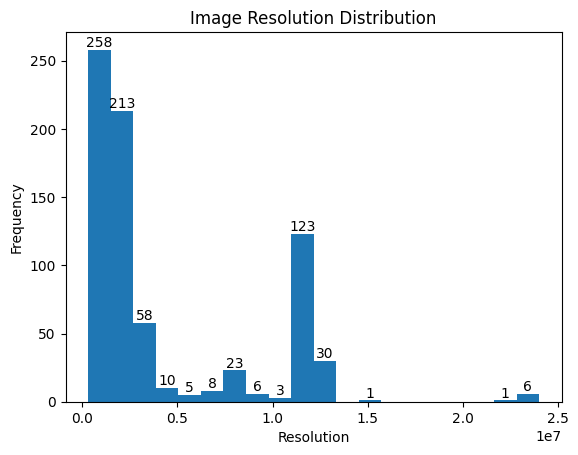

In [79]:
import matplotlib.pyplot as plt

counts, bins, patches = plt.hist(df_full["resolution"], bins=20)

# Add labels on top of each bar
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
            int(count),
            ha='center',
            va='bottom'
        )

plt.title("Image Resolution Distribution")
plt.xlabel("Resolution")
plt.ylabel("Frequency")
plt.show()

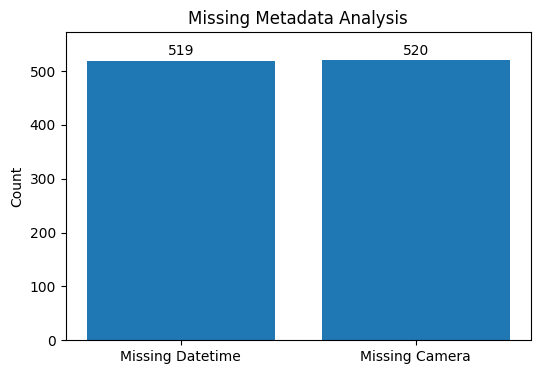

In [80]:
plt.figure(figsize=(6,4))
bars = plt.bar(labels, values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,  # small offset so text is above bar
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Missing Metadata Analysis")
plt.ylabel("Count")
plt.ylim(0, max(values) * 1.1)  # add space for labels
plt.show()

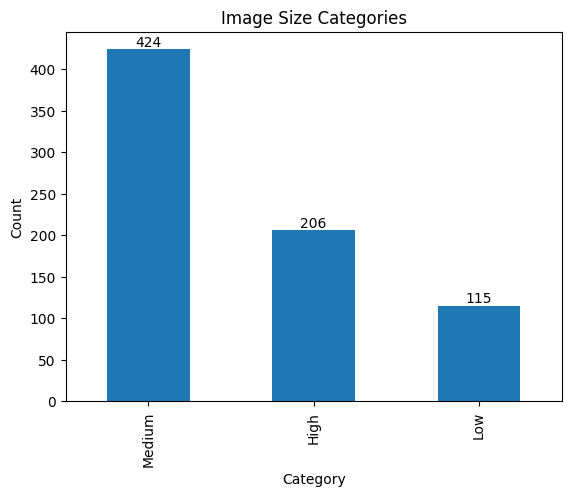

In [81]:
import matplotlib.pyplot as plt

def categorize(res):
    if res < 1_000_000:
        return "Low"
    elif res < 5_000_000:
        return "Medium"
    else:
        return "High"

df_full["size_category"] = df_full["resolution"].apply(categorize)

counts = df_full["size_category"].value_counts()

bars = counts.plot(kind='bar')

# Add labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Image Size Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

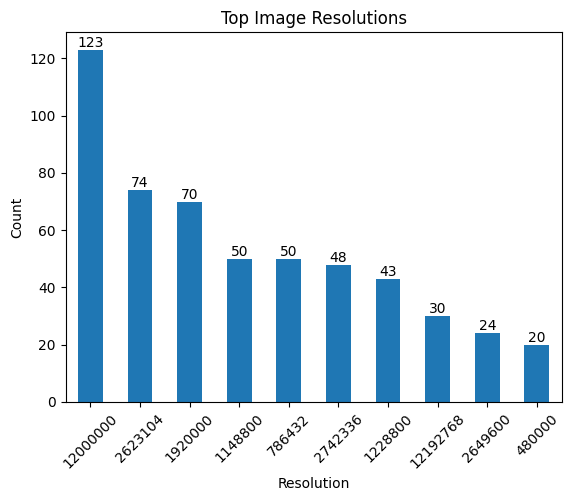

In [82]:

df_full["resolution"] = df_full["width"] * df_full["height"]

top_res = df_full["resolution"].value_counts().head(10)

bars = top_res.plot(kind='bar')

# Add labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Top Image Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

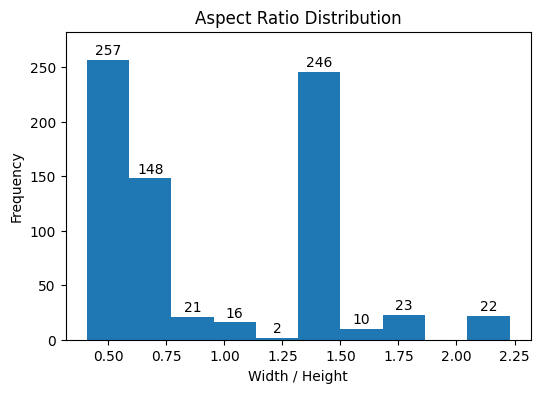

In [83]:
plt.figure(figsize=(6,4))

counts, bins, patches = plt.hist(df_full["aspect_ratio"], bins=10)

for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + 2,
            int(count),
            ha='center',
            va='bottom'
        )

plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Frequency")
plt.ylim(0, max(counts) * 1.1)
plt.show()

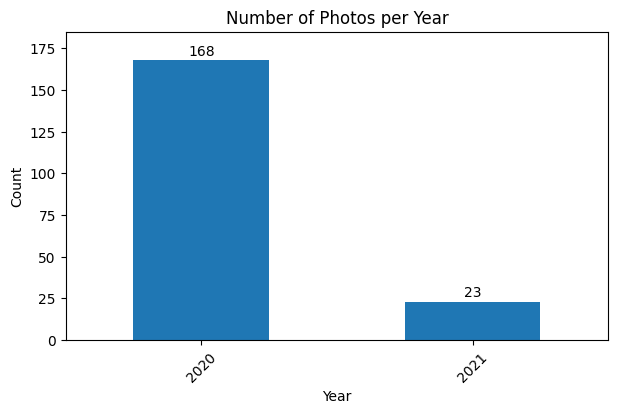

In [84]:
plt.figure(figsize=(7,4))

bars = year_counts.plot(kind='bar')

for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Number of Photos per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.ylim(0, year_counts.max() * 1.1)
plt.xticks(rotation=45)
plt.show()

In [85]:
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import os

def extract_metadata(image_path):
    data = {
        "file_name": os.path.basename(image_path),
        "width": None,
        "height": None,
        "latitude": None,
        "longitude": None
    }

    try:
        img = Image.open(image_path)
        data["width"], data["height"] = img.size

        exif_data = img._getexif()

        if exif_data:
            gps_info = {}

            for tag, value in exif_data.items():
                tag_name = TAGS.get(tag)

                if tag_name == "GPSInfo":
                    for key in value:
                        gps_tag = GPSTAGS.get(key)
                        gps_info[gps_tag] = value[key]

            # Convert GPS to decimal
            if "GPSLatitude" in gps_info and "GPSLongitude" in gps_info:
                def convert(coord):
                    return float(coord[0] + coord[1]/60 + coord[2]/3600)

                lat = gps_info["GPSLatitude"]
                lon = gps_info["GPSLongitude"]

                data["latitude"] = convert(lat)
                data["longitude"] = convert(lon)

    except:
        pass

    return data

In [86]:
metadata_list = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)
            metadata_list.append(extract_metadata(path))

In [87]:
spark_df = spark.createDataFrame(metadata_list)

spark_df.show(5)

+--------------------+------+--------+---------+-----+
|           file_name|height|latitude|longitude|width|
+--------------------+------+--------+---------+-----+
|        IMG_7960.JPG|  2208|    NULL|     NULL| 1242|
|        IMG_0799.JPG|  2208|    NULL|     NULL| 1188|
|ff9d058a-133c-4b2...|  1200|    NULL|     NULL| 1600|
| 20200913_101031.jpg|  1472|    NULL|     NULL| 3264|
|04D52997-78F0-468...|  2160|    NULL|     NULL| 3840|
+--------------------+------+--------+---------+-----+
only showing top 5 rows


In [88]:
from pyspark.sql.functions import col

loc_df = spark_df.filter(
    col("latitude").isNotNull() & col("longitude").isNotNull()
)
print("Total images:", spark_df.count())
print("Images with location:", loc_df.count())

Total images: 745
Images with location: 32


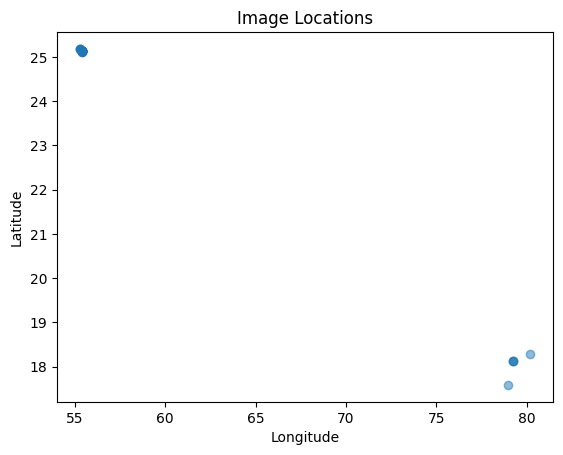

In [89]:
loc_pd = loc_df.toPandas()
import matplotlib.pyplot as plt

plt.scatter(loc_pd["longitude"], loc_pd["latitude"], alpha=0.5)
plt.title("Image Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

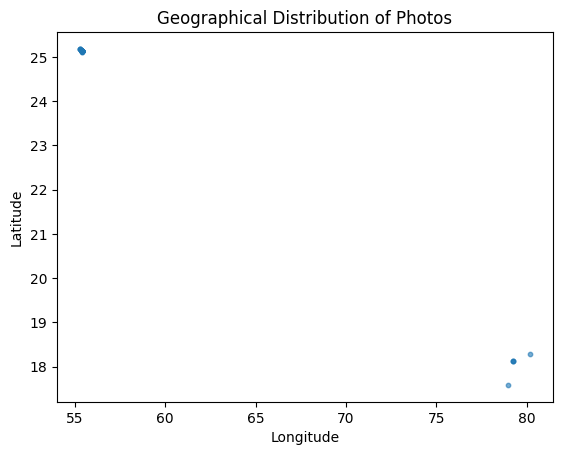

In [90]:
plt.scatter(
    loc_pd["longitude"],
    loc_pd["latitude"],
    s=10,
    alpha=0.6
)
plt.title("Geographical Distribution of Photos")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [91]:
import folium

m = folium.Map(
    location=[loc_pd["latitude"].mean(), loc_pd["longitude"].mean()],
    zoom_start=5
)

for _, row in loc_pd.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3
    ).add_to(m)

m

ModuleNotFoundError: No module named 'folium'